In [1]:
# ============================================
# PROYECTO 4: CLASIFICADOR DE RECICLAJE
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*50)
print("VERIFICANDO CONFIGURACIÓN")
print("="*50)
print(f"TensorFlow version: {tf.__version__}")
print(f"¿GPU disponible?: {tf.config.list_physical_devices('GPU')}")
print("✅ Configuración lista!")

VERIFICANDO CONFIGURACIÓN
TensorFlow version: 2.20.0
¿GPU disponible?: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Configuración lista!


In [2]:
# ============================================
# DESCARGAR DATASET TRASHNET
# ============================================

# Instalar kaggle actualizado
!pip install -q --upgrade kaggle

# Crear carpeta para kaggle
!mkdir -p ~/.kaggle

# Descargar dataset desde Kaggle (con --force para sobrescribir)
!kaggle datasets download -d asdasdasasdas/garbage-classification --force

print("✅ Dataset descargado")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 18.4 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 121MB/s]

✅ Dataset descargado


In [3]:
# ============================================
# DESCOMPRIMIR DATASET
# ============================================

import zipfile
import os

# Descomprimir el ZIP
print("📂 Descomprimiendo dataset...")
with zipfile.ZipFile('garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Dataset descomprimido")

# Verificar que existe la carpeta
if os.path.exists('Garbage classification'):
    print("✅ Carpeta 'Garbage classification' creada")
else:
    print("❌ Error: No se creó la carpeta")

📂 Descomprimiendo dataset...
✅ Dataset descomprimido
✅ Carpeta 'Garbage classification' creada


In [4]:
# ============================================
# PASO 4.2: REORGANIZAR ESTRUCTURA DEL DATASET
# ============================================

import os
import shutil
from pathlib import Path

print("🔄 REORGANIZANDO DATASET...")
print("="*50)

# 1. Crear la estructura correcta
base_dir = 'dataset_correcto'
os.makedirs(f'{base_dir}/train', exist_ok=True)
os.makedirs(f'{base_dir}/test', exist_ok=True)

# 2. Lista de clases
clases = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# 3. Crear carpetas para train y test
for clase in clases:
    os.makedirs(f'{base_dir}/train/{clase}', exist_ok=True)
    os.makedirs(f'{base_dir}/test/{clase}', exist_ok=True)

print("✅ Estructura de carpetas creada")

# 4. Buscar la carpeta fuente
ruta_fuente = 'Garbage classification/Garbage classification'

if os.path.exists(ruta_fuente):
    print(f"✅ Carpeta fuente encontrada: {ruta_fuente}")

    carpetas_clases = os.listdir(ruta_fuente)
    print(f"📁 Clases encontradas: {carpetas_clases}")

    for clase in carpetas_clases:
        if clase in clases:
            ruta_origen = f'{ruta_fuente}/{clase}'

            if os.path.exists(ruta_origen):
                imagenes = os.listdir(ruta_origen)
                print(f"\n📂 Procesando {clase}: {len(imagenes)} imágenes")

                total = len(imagenes)
                train_count = int(total * 0.8)

                for i, img in enumerate(imagenes):
                    ruta_img = f'{ruta_origen}/{img}'

                    if i < train_count:
                        destino = f'{base_dir}/train/{clase}/{img}'
                    else:
                        destino = f'{base_dir}/test/{clase}/{img}'

                    shutil.copy2(ruta_img, destino)

                print(f"   ✅ {clase}: {train_count} train, {total - train_count} test")
else:
    print("❌ No se encontró la carpeta fuente")

print("\n" + "="*50)
print("✅ REORGANIZACIÓN COMPLETADA")

🔄 REORGANIZANDO DATASET...
✅ Estructura de carpetas creada
✅ Carpeta fuente encontrada: Garbage classification/Garbage classification
📁 Clases encontradas: ['plastic', 'cardboard', 'paper', 'metal', 'trash', 'glass']

📂 Procesando plastic: 482 imágenes
   ✅ plastic: 385 train, 97 test

📂 Procesando cardboard: 403 imágenes
   ✅ cardboard: 322 train, 81 test

📂 Procesando paper: 594 imágenes
   ✅ paper: 475 train, 119 test

📂 Procesando metal: 410 imágenes
   ✅ metal: 328 train, 82 test

📂 Procesando trash: 137 imágenes
   ✅ trash: 109 train, 28 test

📂 Procesando glass: 501 imágenes
   ✅ glass: 400 train, 101 test

✅ REORGANIZACIÓN COMPLETADA


In [5]:
# ============================================
# VERIFICAR ESTRUCTURA FINAL
# ============================================

import os

base_dir = 'dataset_correcto'

print("📁 ESTRUCTURA FINAL:")
print("="*50)

if os.path.exists(base_dir):
    print(f"✅ Carpeta '{base_dir}' existe")

    train_path = f'{base_dir}/train'
    if os.path.exists(train_path):
        clases = os.listdir(train_path)
        print(f"\n📂 Train: {len(clases)} clases")

        total_imagenes = 0
        for clase in clases:
            count = len(os.listdir(f'{train_path}/{clase}'))
            print(f"   {clase}: {count} imágenes")
            total_imagenes += count

        print(f"   Total imágenes train: {total_imagenes}")

    test_path = f'{base_dir}/test'
    if os.path.exists(test_path):
        clases = os.listdir(test_path)
        print(f"\n📂 Test: {len(clases)} clases")

        total_imagenes = 0
        for clase in clases:
            count = len(os.listdir(f'{test_path}/{clase}'))
            print(f"   {clase}: {count} imágenes")
            total_imagenes += count

        print(f"   Total imágenes test: {total_imagenes}")

print("="*50)
print("✅ ¡Dataset listo para usar!")

📁 ESTRUCTURA FINAL:
✅ Carpeta 'dataset_correcto' existe

📂 Train: 6 clases
   plastic: 385 imágenes
   cardboard: 322 imágenes
   paper: 475 imágenes
   metal: 328 imágenes
   trash: 109 imágenes
   glass: 400 imágenes
   Total imágenes train: 2019

📂 Test: 6 clases
   plastic: 97 imágenes
   cardboard: 81 imágenes
   paper: 119 imágenes
   metal: 82 imágenes
   trash: 28 imágenes
   glass: 101 imágenes
   Total imágenes test: 508
✅ ¡Dataset listo para usar!


In [6]:
# ============================================
# LIMPIAR ARCHIVOS TEMPORALES
# ============================================

import os
import shutil

print("🧹 LIMPIANDO ARCHIVOS TEMPORALES...")
print("="*50)

# Archivos y carpetas que podemos eliminar
items_to_remove = [
    'garbage-classification.zip',
    'Garbage classification',
    'garbage classification',
    'one-indexed-files-notrash_test.txt',
    'one-indexed-files-notrash_train.txt',
    'one-indexed-files-notrash_val.txt',
    'zero-indexed-files.txt'
]

for item in items_to_remove:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.rmtree(item)
            print(f"✅ Eliminada carpeta: {item}")
        else:
            os.remove(item)
            print(f"✅ Eliminado archivo: {item}")

print("="*50)
print("✅ Limpieza completada")

# Verificar que solo queda dataset_correcto
print("\n📁 Archivos restantes:")
for item in os.listdir('.'):
    if not item.startswith('.'):
        print(f"  {item}")

🧹 LIMPIANDO ARCHIVOS TEMPORALES...
✅ Eliminado archivo: garbage-classification.zip
✅ Eliminada carpeta: Garbage classification
✅ Eliminada carpeta: garbage classification
✅ Eliminado archivo: one-indexed-files-notrash_test.txt
✅ Eliminado archivo: one-indexed-files-notrash_train.txt
✅ Eliminado archivo: one-indexed-files-notrash_val.txt
✅ Eliminado archivo: zero-indexed-files.txt
✅ Limpieza completada

📁 Archivos restantes:
  dataset_correcto
  one-indexed-files.txt
  sample_data


In [7]:
# ============================================
# RENOMBRAR CARPETA FINAL
# ============================================

import os
import shutil

# Renombrar dataset_correcto a dataset
if os.path.exists('dataset_correcto'):
    if os.path.exists('dataset'):
        shutil.rmtree('dataset')
    os.rename('dataset_correcto', 'dataset')
    print("✅ Carpeta renombrada: dataset_correcto → dataset")
else:
    print("❌ No se encontró dataset_correcto")

# Verificar
if os.path.exists('dataset'):
    print("📁 Estructura final:")
    print("✅ dataset/ listo para usar")

✅ Carpeta renombrada: dataset_correcto → dataset
📁 Estructura final:
✅ dataset/ listo para usar


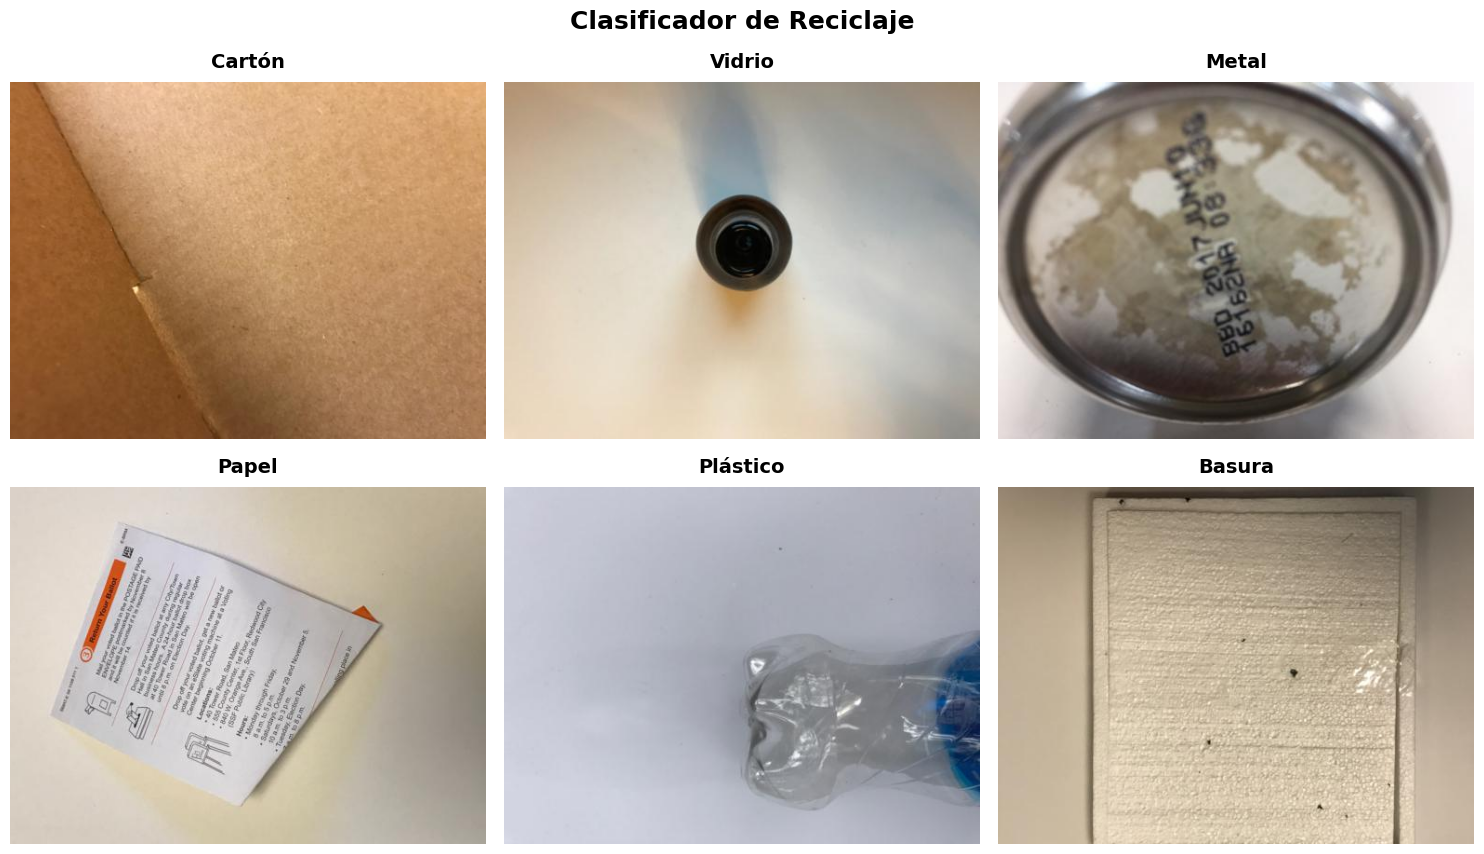


📊 DISTRIBUCIÓN DEL DATASET

CLASE           | ENTRENAMIENTO   | PRUEBA     | TOTAL   
----------------------------------------------------------------------
Cartón          | 322             | 81         | 403     
Vidrio          | 400             | 101        | 501     
Metal           | 328             | 82         | 410     
Papel           | 475             | 119        | 594     
Plástico        | 385             | 97         | 482     
Basura          | 109             | 28         | 137     
----------------------------------------------------------------------
TOTAL           | 2019            | 508        | 2527    

✅ Total de imágenes: 2527
   Entrenamiento: 2019 (79.9%)
   Prueba: 508 (20.1%)


In [10]:
# ============================================
# VISUALIZACIÓN DEL DATASET
# ============================================

import matplotlib.pyplot as plt
import cv2
import os

# Configurar matplotlib para que los títulos se vean mejor
plt.rcParams['font.size'] = 12

# Lista de clases con nombres en español
clases = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
nombres_espanol = {
    'cardboard': 'Cartón',
    'glass': 'Vidrio',
    'metal': 'Metal',
    'paper': 'Papel',
    'plastic': 'Plástico',
    'trash': 'Basura'
}

# Mostrar una imagen de cada clase
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle( 'Clasificador de Reciclaje', fontsize=18, fontweight='bold')

for i, clase in enumerate(clases):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    path = f'dataset/train/{clase}'

    if os.path.exists(path):
        imagenes = os.listdir(path)
        if len(imagenes) > 0:
            img_path = f'{path}/{imagenes[0]}'
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax.imshow(img)
            ax.set_title(f'{nombres_espanol[clase]}', fontsize=14, fontweight='bold', pad=10)
            ax.axis('off')

plt.tight_layout()
plt.show()

# Estadísticas del dataset - Tabla mejor formateada
print("\n" + "="*70)
print("📊 DISTRIBUCIÓN DEL DATASET")
print("="*70)

print(f"\n{'CLASE':<15} | {'ENTRENAMIENTO':<15} | {'PRUEBA':<10} | {'TOTAL':<8}")
print("-"*70)

total_train = 0
total_test = 0
total_general = 0

for clase in clases:
    train_path = f'dataset/train/{clase}'
    test_path = f'dataset/test/{clase}'

    train_count = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
    test_count = len(os.listdir(test_path)) if os.path.exists(test_path) else 0

    nombre = nombres_espanol[clase]
    print(f"{nombre:<15} | {train_count:<15} | {test_count:<10} | {train_count + test_count:<8}")

    total_train += train_count
    total_test += test_count
    total_general += train_count + test_count

print("-"*70)
print(f"{'TOTAL':<15} | {total_train:<15} | {total_test:<10} | {total_general:<8}")
print("="*70)

# Resumen final
print(f"\n✅ Total de imágenes: {total_general}")
print(f"   Entrenamiento: {total_train} ({total_train/total_general*100:.1f}%)")
print(f"   Prueba: {total_test} ({total_test/total_general*100:.1f}%)")